In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_module import PhoDataset, Vocabulary, collate_fn
from src.models.model03 import Encoder, Decoder, Attention, Model03

In [2]:
from typing import Dict
from torch.nn.utils.rnn import pad_sequence

In [27]:
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from torchmetrics.text.rouge import ROUGEScore

# 1. Preparation

## 1.1. Vocabulary

In [4]:
vocab = Vocabulary(
    r'..\data\small-train.json',
    freq_threshold=1
)

                                                 english  \
0                           It begins with a countdown .   
1      On August 14th , 1947 , a woman in Bombay goes...   
2      Across India , people hold their breath for th...   
3      And at the stroke of midnight , a squirming in...   
4      These events form the foundation of " Midnight...   
...                                                  ...   
19995               And the man was incredibly curious .   
19996  And he wanted to understand what it was and wh...   
19997                    And one day , we were walking .   
19998               We were in France , in Les Houches .   
19999               We were up in the mountains , 1976 .   

                                              vietnamese  
0             Câu chuyện bắt đầu với buổi lễ đếm ngược .  
1      Ngày 14 , tháng 8 , năm 1947 , gần nửa đêm , ở...  
2      Cùng lúc , trên khắp đất Ấn , người ta nín thở...  
3      Khi đồng hồ điểm thời khắc nửa đêm ,

## 1.2. Model

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [6]:
INPUT_DIM = vocab.num_en_words
OUTPUT_DIM = vocab.num_vi_words
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 256
N_LAYERS = 3
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

### 1.2.1. `Encoder`, `Attention`, `Decoder`

In [7]:
attn = Attention(HID_DIM)
print(attn)

Attention(
  (W): Linear(in_features=256, out_features=512, bias=True)
)


In [8]:
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
print(enc)

Encoder(
  (embedding): Embedding(17418, 256)
  (rnn): LSTM(256, 256, num_layers=3, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [9]:
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn)
print(dec)

Decoder(
  (attention): Attention(
    (W): Linear(in_features=256, out_features=512, bias=True)
  )
  (embedding): Embedding(7061, 256)
  (rnn): LSTM(256, 256, num_layers=3, dropout=0.5)
  (fc_concat): Linear(in_features=768, out_features=256, bias=True)
  (fc_out): Linear(in_features=256, out_features=7061, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


### 1.2.2. Model

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model03(enc, dec, device).to(device)
print(model)

Model03(
  (encoder): Encoder(
    (embedding): Embedding(17418, 256)
    (rnn): LSTM(256, 256, num_layers=3, dropout=0.5, bidirectional=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (W): Linear(in_features=256, out_features=512, bias=True)
    )
    (embedding): Embedding(7061, 256)
    (rnn): LSTM(256, 256, num_layers=3, dropout=0.5)
    (fc_concat): Linear(in_features=768, out_features=256, bias=True)
    (fc_out): Linear(in_features=256, out_features=7061, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)


## 1.3. Dataset

In [11]:
def collate_fn(
    batch: Dict,
    padding_value: int=0
):
    batch_en = []
    batch_vi = []
    for item in batch:
        batch_en.append(item[0])
        batch_vi.append(item[1])

    en_padded = pad_sequence(batch_en, batch_first=False, padding_value=padding_value)
    vi_padded = pad_sequence(batch_vi, batch_first=False, padding_value=padding_value)

    en_lengths = torch.tensor([len(x) for x in batch_en])
    vi_lengths = torch.tensor([len(x) for x in batch_vi])
    
    return {
        'encoder_input': en_padded,
        'decoder_input': vi_padded,
        'en_lengths': en_lengths,
        'vi_lengths': vi_lengths
    }

In [12]:
def my_collate_fn(batch):
    return collate_fn(batch, padding_value=vocab.en2i['<PAD>'])

In [13]:
train_df = PhoDataset(
    '..\data\small-train.json',
    vocab
)
train_loader = DataLoader(
    train_df,
    batch_size = 64,
    shuffle=True,
    collate_fn=my_collate_fn,
    num_workers=0,
    drop_last=True,
)

In [14]:
dev_df = PhoDataset(
    '..\data\small-dev.json',
    vocab
)
dev_loader = DataLoader(
    dev_df,
    batch_size = 64,
    shuffle=False,
    collate_fn=my_collate_fn,
    num_workers=0,
    drop_last=True,
)

In [15]:
test_df = PhoDataset(
    '..\data\small-test.json',
    vocab
)
test_loader = DataLoader(
    test_df,
    batch_size = 64,
    shuffle=False,
    collate_fn=my_collate_fn,
    num_workers=0,
    drop_last=True,
)

# 2. Training

## 2.1. Per epoch

### 2.1.1. Epoch training

In [16]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
TRG_PAD_IDX = vocab.vi2i['<PAD>']
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

In [17]:
def train_epoch(model, loader, optimizer, criterion, device, clip=1.0):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(loader, desc='Training', leave=True)
    
    for batch in progress_bar:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        
        optimizer.zero_grad()
        
        trg_input = trg[:-1, :] 
        trg_target = trg[1:, :] 
        
        output = model(src, trg_input)
        
        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim)
        trg_target = trg_target.reshape(-1)
        
        loss = criterion(output, trg_target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
        
    return epoch_loss / len(loader)

In [18]:
def evaluate(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        progress_bar = tqdm(loader, desc='Evaluating', leave=True)
        for batch in progress_bar:
            src = batch['encoder_input'].to(device)
            trg = batch['decoder_input'].to(device)

            trg_input = trg[:-1, :]
            trg_target = trg[1:, :]
            output = model(src, trg_input, teacher_forcing_ratio=0)
            
            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            trg_target = trg_target.reshape(-1)
            
            loss = criterion(output, trg_target)
            epoch_loss += loss.item()
            
            progress_bar.set_postfix({'val_loss': loss.item()})
            
    return epoch_loss / len(loader)

### 2.2. Training

In [19]:
N_EPOCHS = 10
best_valid_loss = float('inf')

In [20]:
def training(
    model,
    train_loader,
    dev_loader,
    optimizer,
    criterion,
    device,
    num_epochs = 10,
    best_valid_loss = float('inf'),
    save_path = '../checkpoints/best_model03.pt'
):
    training_loss = []
    evaluating_loss = []

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        valid_loss = evaluate(model, dev_loader, criterion, device)
        
        training_loss.append(train_loss)
        evaluating_loss.append(valid_loss)
        
        print(f'\n' + '='*30)
        print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.4f} | Val. Loss: {valid_loss:.4f}')
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss

            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            
            torch.save(model.state_dict(), save_path)
            print(f"\t [!] New Best Valid Loss. Model saved to {save_path}")
            
        print('='*30 + '\n')

        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return training_loss, evaluating_loss

In [21]:
mode = False
if mode == 'training':
    result = training(
        model, 
        train_loader, 
        dev_loader, 
        optimizer, 
        criterion, 
        device
    )

## 2.3. Finetuning trained model

In [ ]:
def finetune(
    model, 
    train_loader, 
    dev_loader, 
    criterion, 
    device, 
    num_epochs=5,
    learning_rate=0.002,
    save_path='../checkpoints/finetuned_model03.pt'
):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_valid_loss = float('inf')
    ft_train_losses = []
    ft_val_losses = []
    
    print(f"Starting Fine-tuning with LR={learning_rate}...")
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        valid_loss = evaluate(model, dev_loader, criterion, device)
        ft_train_losses.append(train_loss)
        ft_val_losses.append(valid_loss)
        
        print(f'\nEpoch: {epoch+1:02} | FT Train Loss: {train_loss:.4f} | FT Val. Loss: {valid_loss:.4f}')

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), save_path)
            print(f"\t [!] New Best Fine-tuned Model saved.")
        print('='*30)
        
    return ft_train_losses, ft_val_losses

In [23]:
model = Model03(enc, dec, device).to(device)
model.load_state_dict(torch.load('../checkpoints/best_model03.pt'))

criterion = nn.CrossEntropyLoss(ignore_index=vocab.vi2i['<PAD>'])

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_2236\4279025721.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/best_model0

In [24]:
history = finetune(
    model, 
    train_loader, 
    dev_loader, 
    criterion, 
    device,
    num_epochs=5,
    learning_rate=0.002,
    save_path='../checkpoints/finetuned_model03.pt'
)

Starting Fine-tuning with LR=0.002...


Evaluating: 100%|██████████| 31/31 [00:02<00:00, 10.82it/s, val_loss=6.15]



Epoch: 01 | FT Train Loss: 6.0913 | FT Val. Loss: 6.1092
	 [!] New Best Fine-tuned Model saved.


Evaluating: 100%|██████████| 31/31 [00:02<00:00, 10.86it/s, val_loss=6.12]



Epoch: 02 | FT Train Loss: 5.9857 | FT Val. Loss: 6.0869
	 [!] New Best Fine-tuned Model saved.


...


Epoch: 03 | FT Train Loss: 5.9137 | FT Val. Loss: 6.0502
	 [!] New Best Fine-tuned Model saved.


Evaluating: 100%|██████████| 31/31 [00:03<00:00, 10.33it/s, val_loss=6.06]



Epoch: 04 | FT Train Loss: 5.8424 | FT Val. Loss: 6.0211
	 [!] New Best Fine-tuned Model saved.


Evaluating: 100%|██████████| 31/31 [00:04<00:00,  7.31it/s, val_loss=6]   


Epoch: 05 | FT Train Loss: 5.7711 | FT Val. Loss: 5.9624
	 [!] New Best Fine-tuned Model saved.


In [32]:
finetuning_training_loss, finetuning_eval_loss = history
print(len(finetuning_training_loss))

5


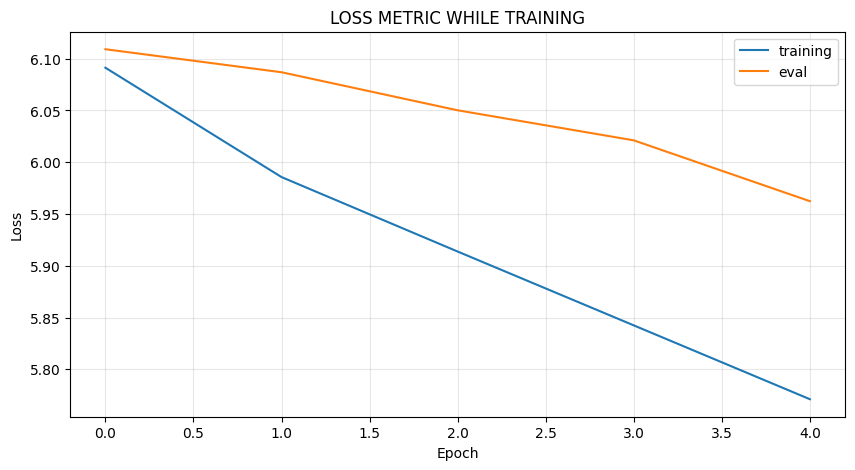

In [41]:
plt.figure(figsize=(10, 5))
plt.plot([i for i in range(5)], finetuning_training_loss, label = 'training')
plt.plot([i for i in range(5)], finetuning_eval_loss, label = 'eval')

plt.title('LOSS METRIC WHILE TRAINING')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha = 0.3)

# 3. Evaluation

In [42]:
def evaluate_rouge(model, loader, vocab, device, max_len=50):
    model.eval()
    rouge_metric = ROUGEScore(rouge_keys='rougeL')
    
    predictions = []
    references = []
    
    progress_bar = tqdm(loader, desc='Calculating ROUGE-L', leave=True)

    with torch.no_grad():
        for batch in progress_bar:

            src = batch['encoder_input'].to(device)
            trg = batch['decoder_input']
            
            batch_size = src.shape[1] 

            for i in range(batch_size):
                single_src = src[:, i:i+1]
                enc_outputs, hidden, cell = model.encoder(single_src)
                
                trg_indexes = [vocab.vi2i['<SOS>']]
                
                for _ in range(max_len):
                    trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)

                    output, hidden, cell = model.decoder(trg_tensor, hidden, cell, enc_outputs)
                    
                    pred_token = output.argmax(1).item()
                    trg_indexes.append(pred_token)
                    
                    if pred_token == vocab.vi2i['<EOS>']:
                        break
                
                def tokens_to_sentence(ids, vocabulary, is_vi=True):
                    specials = {vocabulary.vi2i['<SOS>'], vocabulary.vi2i['<EOS>'], vocabulary.vi2i['<PAD>']}
                    vocab_map = vocabulary.i2vi if is_vi else vocabulary.i2en
                    return " ".join([vocab_map[idx] for idx in ids if idx not in specials and idx in vocab_map])

                pred_sentence = tokens_to_sentence(trg_indexes, vocab)
                actual_sentence = tokens_to_sentence(trg[:, i].tolist(), vocab)
                
                predictions.append(pred_sentence)
                references.append(actual_sentence)

    results = rouge_metric(predictions, references)
    return results['rougeL_fmeasure'].item()

In [43]:
model.load_state_dict(torch.load('../checkpoints/finetuned_model03.pt'))

print("--- Bắt đầu tính điểm ROUGE-L ---")
score = evaluate_rouge(model, test_loader, vocab, device)

print(f"\n" + "="*40)
print(f"KẾT QUẢ ĐÁNH GIÁ (TEST SET)")
print(f"ROUGE-L Score: {score:.4f} ({score*100:.2f}%)")
print("="*40)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_2236\4083143339.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/finetuned_m

--- Bắt đầu tính điểm ROUGE-L ---


Calculating ROUGE-L: 100%|██████████| 31/31 [00:58<00:00,  1.90s/it]



KẾT QUẢ ĐÁNH GIÁ (TEST SET)
ROUGE-L Score: 0.2133 (21.33%)
